In [1]:
import os
import sqlite3
import struct
from io import BytesIO
import tarfile
import logging

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from dotenv import load_dotenv
from transformers import AutoProcessor, AutoModel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from schema import setup_db
from hotdog import initial_setup

%load_ext autoreload
%autoreload 2

load_dotenv()
setup_db()

DB = os.environ.get('DB', 'embedding.db')
FOOD_TAR_PATH = os.environ.get('FOOD_TAR_PATH')
MODEL_NAME = 'siglip'

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

processor = AutoProcessor.from_pretrained("google/siglip-base-patch16-224")
model = AutoModel.from_pretrained("google/siglip-base-patch16-224").to(device)
model.eval()

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

SiglipModel(
  (text_model): SiglipTextModel(
    (embeddings): SiglipTextEmbeddings(
      (token_embedding): Embedding(32000, 768)
      (position_embedding): Embedding(64, 768)
    )
    (encoder): SiglipEncoder(
      (layers): ModuleList(
        (0-11): 12 x SiglipEncoderLayer(
          (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attn): SiglipAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): SiglipMLP(
            (activation_fn): GELUTanh()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, 

In [3]:
%%time
df = initial_setup(model=MODEL_NAME)

  0%|          | 0/101112 [00:00<?, ?it/s]

CPU times: user 16.3 s, sys: 1.03 s, total: 17.3 s
Wall time: 1min 44s


In [4]:
%%time
# SigLIP image embeddings are 768-dimensional (base patch16).
EMBEDDING_DIM = 768
EMBEDDING_FMT = f'{EMBEDDING_DIM}f'

with sqlite3.connect(DB) as conn:
    sql = f"SELECT id FROM embeddings WHERE embedding IS NOT NULL AND model = '{MODEL_NAME}'"
    known_ids = set(pd.read_sql(sql, conn)['id'].tolist())
print(len(known_ids))

with tarfile.open(FOOD_TAR_PATH, 'r:gz') as tar:
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        if row['id'] in known_ids:
            continue
        member = tar.getmember(row['path'])
        try:
            with tar.extractfile(member) as member_file:
                image = Image.open(BytesIO(member_file.read())).convert('RGB')
                inputs = processor(images=image, return_tensors='pt').to(device)
                with torch.no_grad():
                    out = model.get_image_features(**inputs)
                v = out.pooler_output[0].cpu().numpy().tolist()
                with sqlite3.connect(DB) as conn:
                    sql = 'UPDATE embeddings SET embedding = ? WHERE id = ? AND model = ?'
                    conn.execute(sql, (struct.pack(EMBEDDING_FMT, *v), row['id'], MODEL_NAME))
        except Exception as ex:
            logging.error(ex)
            logging.error(row['path'])

21626


  0%|          | 0/101000 [00:00<?, ?it/s]

CPU times: user 32min 22s, sys: 4min 5s, total: 36min 28s
Wall time: 1h 51min 58s


In [5]:
MODEL_NAME

'siglip'

In [6]:
with sqlite3.connect(DB) as conn:
    sql = f"SELECT * FROM embeddings WHERE model = '{MODEL_NAME}'"
    embeddings_df = pd.read_sql(sql, conn)
embeddings_df['embedding'] = embeddings_df['embedding'].map(
    lambda x: np.array(struct.unpack(EMBEDDING_FMT, x))
)
embeddings_df

,id,model,path,label,embedding
0,2885220,siglip,food-101/images/beignets/2885220.jpg,beignets,"[0.25701582431793213, 0.2724393606185913, 0.21..."
1,1814040,siglip,food-101/images/beignets/1814040.jpg,beignets,"[0.12035908550024033, 0.017058521509170532, -0..."
2,81202,siglip,food-101/images/beignets/81202.jpg,beignets,"[0.07127691805362701, -0.46735063195228577, 0...."
3,1827892,siglip,food-101/images/beignets/1827892.jpg,beignets,"[0.1275012493133545, -0.22540763020515442, 0.3..."
4,2802124,siglip,food-101/images/beignets/2802124.jpg,beignets,"[0.7015612125396729, 0.13412073254585266, 0.29..."
...,...,...,...,...,...
100995,2635081,siglip,food-101/images/spaghetti_bolognese/2635081.jpg,spaghetti_bolognese,"[-0.03593221306800842, -0.6152750253677368, -0..."
100996,3614721,siglip,food-101/images/spaghetti_bolognese/3614721.jpg,spaghetti_bolognese,"[-0.07527279853820801, -0.08851253986358643, -..."
100997,1277517,siglip,food-101/images/spaghetti_bolognese/1277517.jpg,spaghetti_bolognese,"[-0.12035083770751953, -0.4596394896507263, -0..."
100998,3353469,siglip,food-101/images/spaghetti_bolognese/3353469.jpg,spaghetti_bolognese,"[0.29306653141975403, -0.43574652075767517, -0..."


In [7]:
with open('labels.txt') as f:
    label_txt = [l.strip() for l in f.readlines()]
with open('classes.txt') as f:
    classes_txt = [l.strip() for l in f.readlines()]

# Encode all label texts with SigLIP's text encoder.
inputs = processor(text=label_txt, return_tensors='pt', padding='max_length').to(device)
with torch.no_grad():
    text_out = model.get_text_features(**inputs)
text_features = text_out.pooler_output  # (101, 768)

# Normalize for cosine similarity.
text_features = text_features / text_features.norm(dim=-1, keepdim=True)
text_features_np = text_features.cpu().numpy()

In [8]:
%%time
# Predict by cosine similarity between image and text embeddings.
predictions = {}
img_matrix = np.stack(embeddings_df['embedding'].tolist())
img_matrix = img_matrix / np.linalg.norm(img_matrix, axis=1, keepdims=True)
sims = img_matrix @ text_features_np.T  # (N, 101)
pred_indices = np.argmax(sims, axis=1)
for (_, row), pred_idx in zip(embeddings_df.iterrows(), pred_indices):
    predictions[row['id']] = classes_txt[pred_idx]

CPU times: user 2 s, sys: 822 ms, total: 2.82 s
Wall time: 2.95 s


In [9]:
with sqlite3.connect(DB) as conn:
    sql = 'INSERT OR IGNORE INTO predictions (id, model, predicted_label) VALUES (?, ?, ?)'
    conn.executemany(sql, [(k, MODEL_NAME, v) for k, v in predictions.items()])

In [10]:
%%time
with sqlite3.connect(DB) as conn:
    sql = f'''
    SELECT embeddings.*, predicted_label
    FROM embeddings
    LEFT JOIN predictions
        ON embeddings.id = predictions.id AND embeddings.model = predictions.model
    WHERE embeddings.model = '{MODEL_NAME}'
    '''
    combined_df = pd.read_sql(sql, conn)
combined_df['embedding'] = combined_df['embedding'].map(
    lambda x: np.array(struct.unpack(EMBEDDING_FMT, x))
)
combined_df

CPU times: user 4.03 s, sys: 725 ms, total: 4.76 s
Wall time: 5.65 s


,id,model,path,label,embedding,predicted_label
0,2885220,siglip,food-101/images/beignets/2885220.jpg,beignets,"[0.25701582431793213, 0.2724393606185913, 0.21...",beignets
1,1814040,siglip,food-101/images/beignets/1814040.jpg,beignets,"[0.12035908550024033, 0.017058521509170532, -0...",beignets
2,81202,siglip,food-101/images/beignets/81202.jpg,beignets,"[0.07127691805362701, -0.46735063195228577, 0....",beignets
3,1827892,siglip,food-101/images/beignets/1827892.jpg,beignets,"[0.1275012493133545, -0.22540763020515442, 0.3...",beignets
4,2802124,siglip,food-101/images/beignets/2802124.jpg,beignets,"[0.7015612125396729, 0.13412073254585266, 0.29...",beignets
...,...,...,...,...,...,...
100995,2635081,siglip,food-101/images/spaghetti_bolognese/2635081.jpg,spaghetti_bolognese,"[-0.03593221306800842, -0.6152750253677368, -0...",spaghetti_bolognese
100996,3614721,siglip,food-101/images/spaghetti_bolognese/3614721.jpg,spaghetti_bolognese,"[-0.07527279853820801, -0.08851253986358643, -...",spaghetti_bolognese
100997,1277517,siglip,food-101/images/spaghetti_bolognese/1277517.jpg,spaghetti_bolognese,"[-0.12035083770751953, -0.4596394896507263, -0...",spaghetti_bolognese
100998,3353469,siglip,food-101/images/spaghetti_bolognese/3353469.jpg,spaghetti_bolognese,"[0.29306653141975403, -0.43574652075767517, -0...",spaghetti_bolognese


In [11]:
# Overall accuracy
accuracy = (combined_df['label'] == combined_df['predicted_label']).sum() / len(combined_df)
print(f'Overall accuracy: {accuracy:.4f}')

Overall accuracy: 0.8969


In [12]:
# False Negatives: hot dogs predicted as something else
mask = combined_df['label'] == 'hot_dog'
fn_accuracy = (combined_df[mask]['label'] == combined_df[mask]['predicted_label']).sum() / len(combined_df[mask])
print(f'Hot dog recall: {fn_accuracy:.4f}')
combined_df[mask].groupby('predicted_label').count().sort_values('id', ascending=False)

Hot dog recall: 0.9290


,id,model,path,label,embedding
predicted_label,,,,,
hot_dog,929,929,929,929,929
hamburger,10,10,10,10,10
pulled_pork_sandwich,9,9,9,9,9
lobster_roll_sandwich,7,7,7,7,7
foie_gras,6,6,6,6,6
club_sandwich,5,5,5,5,5
poutine,5,5,5,5,5
croque_madame,3,3,3,3,3
onion_rings,3,3,3,3,3


In [13]:
# False Positives: non-hot-dogs predicted as hot dog
mask = combined_df['predicted_label'] == 'hot_dog'
fp_precision = (combined_df[mask]['label'] == combined_df[mask]['predicted_label']).sum() / len(combined_df[mask])
print(f'Hot dog precision: {fp_precision:.4f}')
combined_df[mask].groupby('label').count().sort_values('id', ascending=False)

Hot dog precision: 0.9548


,id,model,path,embedding,predicted_label
label,,,,,
hot_dog,929,929,929,929,929
pulled_pork_sandwich,8,8,8,8,8
lobster_roll_sandwich,5,5,5,5,5
falafel,4,4,4,4,4
croque_madame,3,3,3,3,3
french_fries,3,3,3,3,3
club_sandwich,2,2,2,2,2
grilled_cheese_sandwich,2,2,2,2,2
hamburger,2,2,2,2,2


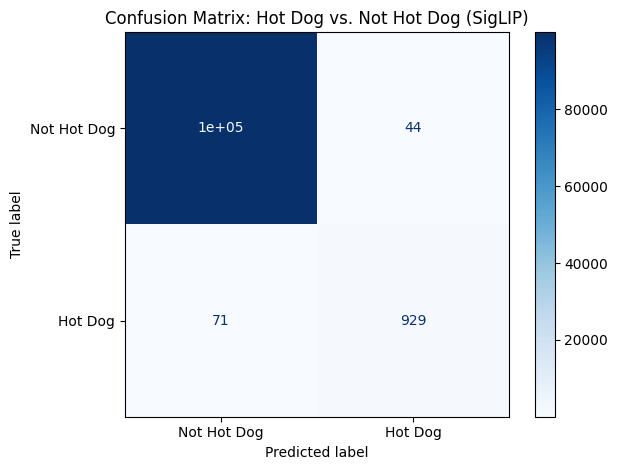

In [14]:
y_true = (combined_df['label'] == 'hot_dog').astype(int)
y_pred = (combined_df['predicted_label'] == 'hot_dog').astype(int)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Hot Dog', 'Hot Dog'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Hot Dog vs. Not Hot Dog (SigLIP)')
plt.tight_layout()
plt.show()